In [4]:
%matplotlib inline
import torch
from torch import nn
import d2l

## Generate data

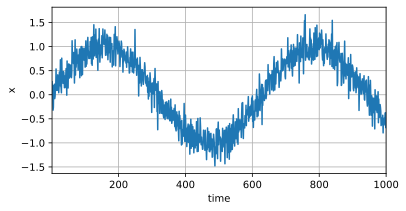

In [5]:
T = 1000
time = torch.arange(1,T+1,dtype=torch.float32)
x = torch.sin(0.01 * time) + torch.normal(0,0.2,(T,))
d2l.plot(time,[x],'time','x',xlim=[1,1000],figsize=(6,3))

## Transform the sequence into feature-labe

In [7]:
tau  = 4
features = torch.zeros((T-tau, tau))
for i in range(tau):
    features[:,i] = x[i:T-tau+i]
labels = x[tau:].reshape((-1,1)) 

In [8]:
batch_size, n_train = 16,600
train_iter = d2l.load_array((features[:n_train], labels[:n_train]),batch_size,is_train=True)

## Define Model

In [10]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)

def get_net():
    net = nn.Sequential(
        nn.Linear(4,10),
        nn.ReLU(),
        nn.Linear(10,1)
    )
    net.apply(init_weights)
    return net

loss = nn.MSELoss(reduction='none')

## Train

In [12]:
def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(),lr)
    for epoch in range(epochs):
        for X,y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.sum().backward()
            trainer.step()
        print(f'epoch{epoch + 1}, '
              f'loss: {d2l.evaluate_loss(net, train_iter, loss):f}')

net = get_net()
train(net, train_iter, loss, 5, 0.01)

epoch1, loss: 0.067727
epoch2, loss: 0.062489
epoch3, loss: 0.062262
epoch4, loss: 0.056105
epoch5, loss: 0.052540


/home/kj/Documents/Projects/Dive_into_deep_learning/d2l.py:3179: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  self.data = [a + float(b) for a, b in zip(self.data, args)]


## Prediction for onestep

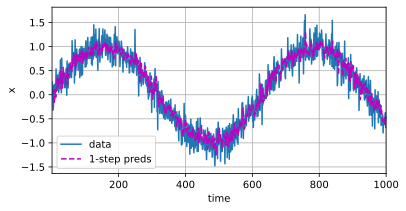

In [15]:
onestep_preds = net(features)
d2l.plot([time, time[tau:]],
         [x.detach().numpy(), onestep_preds.detach().numpy()], 'time',
         'x', legend=['data', '1-step preds'], xlim=[1,1000],
         figsize=(6,3))

## k-step-ahead-prediction

In [17]:
multistep_preds = torch.zeros(T)
multistep_preds[: n_train+tau] = x[:n_train+tau]
for i in range(n_train+tau, T):
    multistep_preds[i] = net(
            multistep_preds[i-tau:i].reshape((1,-1))
    )

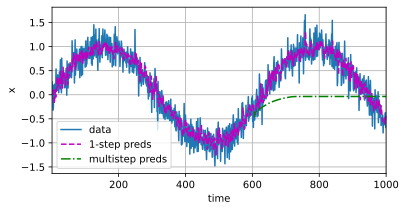

In [20]:
d2l.plot([time, time[tau:], time[n_train + tau:]],
         [x.detach().numpy(), onestep_preds.detach().numpy(), multistep_preds[n_train+tau:].detach().numpy()], 'time',
         'x', legend=['data', '1-step preds', 'multistep preds'], xlim=[1,1000],
         figsize=(6,3))

## Summary

From the example above, the k-step prediction is not ideal, the prediction result quickly decays to a constant. Why? Since the accumulation of errors. Suppose after step 1, we accumulate some error e_1 = average e, then the input from step 2 will be perturbed by e_1, then e_2 = average e + c*e_1, where c is a constant.